<a href="https://colab.research.google.com/github/m5aad/Pairs-trading-Backtester/blob/main/Pairs_trading_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================
# FRESH COLAB GITHUB SETUP
# ==============================

import getpass
import subprocess
import os

# 1. Install GitHub CLI
!apt-get -qq update
!apt-get -qq install gh

# 2. Enter your GitHub PAT securely
#    Nothing will appear while you type/paste it.
pat = getpass.getpass("Paste your GitHub PAT: ")

# 3. Authenticate GitHub CLI
result = subprocess.run(
    ["gh", "auth", "login", "--with-token"],
    input=pat + "\n",
    text=True,
    capture_output=True
)

if result.returncode != 0:
    print("Authentication failed:")
    print(result.stderr)
else:
    print("GitHub authentication successful!")

# Remove PAT from Python variable
del pat

# 4. Clone your repository
repo = "m5aad/Pairs-trading-Backtester"
repo_dir = "/content/Pairs-trading-Backtester"

if not os.path.exists(repo_dir):
    !gh repo clone {repo} {repo_dir}
else:
    print("Repository already exists in this runtime.")

# 5. Enter repository
%cd /content/Pairs-trading-Backtester

# 6. Install project requirements
if os.path.exists("requirements.txt"):
    !pip install -q -r requirements.txt
else:
    print("No requirements.txt found.")

# 7. Check Git status
!git status

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Paste your GitHub PAT: ··········
GitHub authentication successful!
Cloning into '/content/Pairs-trading-Backtester'...
remote: Enumerating objects: 66, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 66 (delta 26), reused 37 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (66/66), 319.90 KiB | 12.80 MiB/s, done.
Resolving deltas: 100% (26/26), done.
/content/Pairs-trading-Backtester
No requirements.txt found.
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


XOM vs CVX Pairs Trading

This notebook investigates a mean-reversion pairs trading strategy using
Exxon Mobil (XOM) and Chevron (CVX).

The strategy:
- estimates a rolling regression between XOM and CVX
- calculates the regression residual
- standardises the residual using a rolling z-score
- enters trades when the z-score reaches predefined thresholds
- exits when the z-score returns towards zero
- evaluates the strategy using P/L, Sharpe ratio, drawdown,
  profit factor and win rate

The analysis is divided into an optimisation/training stage and
an out-of-sample testing stage.


In [ ]:
import scipy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 1000)

window = 240

Helper functions

In [ ]:
def reversion_checker(signals, residuals):
    reversion_rates = []
    for k in [5, 10, 20, 40]:
        reverted = 0
        observations = 0
        for j in signals:
            if abs(residuals[j]) > abs(residuals[j + k]):
                reverted += 1
            observations += 1
        reversion_rates.append(reverted/observations)
    return reversion_rates

Backtesting functions

In [ ]:
def pl_tester(upper, lower):
    df = pd.DataFrame({'Date' : xom.dates,
                       'CVX' : cvx.prices,
                       'XOM' : xom.prices,
                       'beta' : betas,
                       'Residuals': residuals
                       })

    df['rolling mean'] = df['Residuals'].rolling(window).mean()
    df['rolling stds'] = df['Residuals'].rolling(window).std()
    df['rolling z scores'] = (df['Residuals'] - df['rolling mean'])/df['rolling stds']

    positions=[0]
    for i in range(1,len(df)):
        if df['rolling z scores'][i] > upper:
            positions.append(-1)
        elif df['rolling z scores'][i] < lower:
            positions.append(1)
        elif abs(df['rolling z scores'][i]) < 0.5:
            positions.append(0)
        else:
            positions.append(positions[i-1])
    df['positions'] = positions
    df['xom return pct'] = df['XOM'].pct_change()
    df['cvx return pct'] = df['CVX'].pct_change()

    entry_betas = [0]
    entry_index = []
    for i in range(1, len(df)):
        if df['positions'][i] != 0 and df['positions'][i] != df['positions'][i-1]:
            entry_betas.append(df['beta'][i])
            entry_index.append(i)
        elif df['positions'][i] == df['positions'][i-1]:
            entry_betas.append(entry_betas[i-1])
        else:
            entry_betas.append(0)
    df['entry_betas'] = entry_betas

    xom_notional = [0]*(len(df))
    cvx_notional = [0]*(len(df))
    xom_daily_pl = [0]*(len(df))
    cvx_daily_pl = [0]*(len(df))

    base_cost = 1000
    # print(entry_index)
    # print(len(entry_index))
    trade_length = []
    for i in entry_index:
        trading = True
        trade_days=1
        xom_notional[i] = df['positions'][i] * base_cost
        cvx_notional[i] = -1 * df['positions'][i] * base_cost * df['entry_betas'][i]
        while trading:
            xom_daily_pl[i + trade_days] = xom_notional[i + trade_days - 1] * df['xom return pct'][i + trade_days]
            cvx_daily_pl[i + trade_days] = cvx_notional[i + trade_days - 1] * df['cvx return pct'][i + trade_days]

            if df['positions'][i + trade_days] != df['positions'][i + trade_days - 1] and abs(df['positions'][i + trade_days - 1]) == 1:
                trading = False
                trade_length.append(trade_days)
            else:
                xom_notional[i + trade_days] = xom_notional[i + trade_days - 1]
                cvx_notional[i + trade_days] = cvx_notional[i + trade_days - 1]
                trade_days += 1
            if i+trade_days == len(df):
                trade_length.append(trade_days-1)
                break

    df['xom notional'] = xom_notional
    df['cvx notional'] = cvx_notional
    df['xom p/l'] = xom_daily_pl
    df['cvx p/l'] = cvx_daily_pl
    df['daily p/l'] = df['xom p/l'] + df['cvx p/l']
    df['cumulative p/l'] = df['daily p/l'].cumsum()
    opening_pl = df['cumulative p/l'][entry_index]
    closing_pl = df['cumulative p/l'][np.add(entry_index, trade_length)]
    per_trade_p_l = closing_pl.values - opening_pl.values
    return df, len(entry_index), per_trade_p_l

In [ ]:
def vary_upper_lower():
    uppers = np.round(np.linspace(1, 3, 11), 1)
    lowers = np.round(np.linspace(-3, -1    , 11), 1)
    pl_results = np.empty((11,11))
    annualised_sharpes = np.empty((11,11))
    winrates = np.empty((11,11))
    max_drawdowns = np.empty((11,11))
    profit_factors = np.empty((11,11))
    n_trades = np.empty((11,11))
    for i in range(len(uppers)):
        for j in range(len(lowers)):
            wincount, totalwin, losscount, totalloss = (0, 0, 0, 0)
            temp, ntrades, trade_pl = pl_tester(uppers[i], lowers[j])
            pl_results[i, j] = temp['cumulative p/l'].iloc[-1]
            mean_daily_return = temp['daily p/l'].mean()
            std_daily_return = temp['daily p/l'].std()
            sharpe_daily = mean_daily_return / std_daily_return
            annualised_sharpes[i, j] = sharpe_daily * np.sqrt(252)
            n_trades[i, j] = ntrades
            for net in trade_pl:
                if net > 0:
                    wincount += 1
                    totalwin += net
                elif net < 0:
                    losscount += 1
                    totalloss += net
            if losscount == 0:
                avg_loss = 0
            else:
                avg_loss = totalloss / losscount
            if wincount == 0:
                avg_win = 0
            else:
                avg_win = totalwin / wincount
            if totalloss == 0:
                profit_factor = np.nan
            else:
                profit_factor = totalwin / abs(totalloss)
            winrate = wincount / ntrades
            running_max = temp['cumulative p/l'].cummax()
            drawdown = temp['cumulative p/l'] - running_max
            max_drawdown = drawdown.min()
            max_drawdowns[i, j] = max_drawdown
            winrates[i, j] = winrate
            profit_factors[i, j] = profit_factor

    return uppers, lowers, pl_results, annualised_sharpes, winrates, max_drawdowns, profit_factors, n_trades

1. Data handling

In [ ]:
class Stock:
    def __init__(self, filename):
        temp = pd.read_csv(filename)
        self.prices = temp['Close-Last']
        self.dates = (np.array(temp['Date'].tolist(), dtype='datetime64'))

In [ ]:
xom = Stock('XOM_training.csv')
cvx = Stock('CVX_training.csv')

2. Rolling regression

In [ ]:
alphas = [np.nan] * window
betas = [np.nan] * window

for i in range(window, len(cvx.prices)):
    rolling_cvx_prices = cvx.prices[i - window:i]
    rolling_xom_prices = xom.prices[i - window:i]
    b, a, r, p, se = sp.stats.linregress(
        rolling_cvx_prices,
        rolling_xom_prices
    )
    alphas.append(a)
    betas.append(b)

In [ ]:
residuals = xom.prices - alphas - betas * cvx.prices

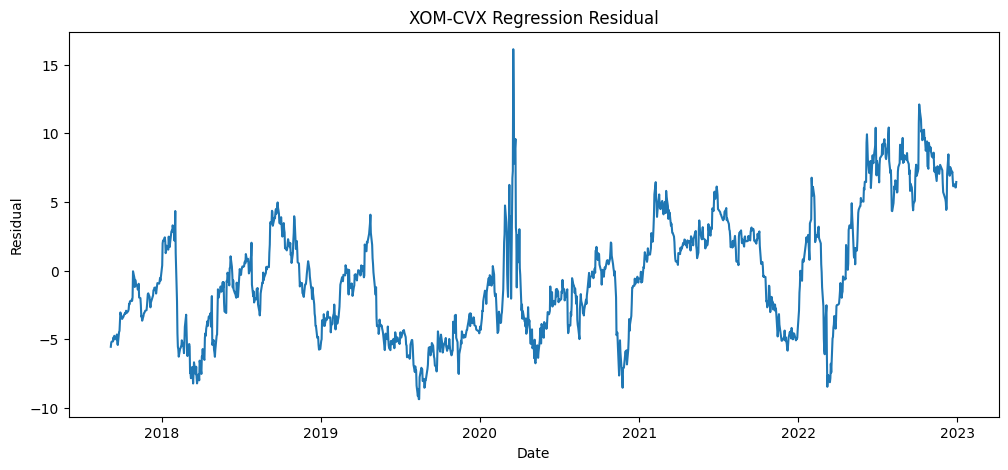

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(xom.dates, residuals)
plt.title("XOM-CVX Regression Residual")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

3. Training / Parameter optimisation

In [ ]:
xom = Stock('XOM_training.csv')
cvx = Stock('CVX_training.csv')
uppers, lowers, pl_res, ann_sharpes, winrates, max_drawdowns, profitfactors, ntrades = vary_upper_lower()

Parameter optimisation results

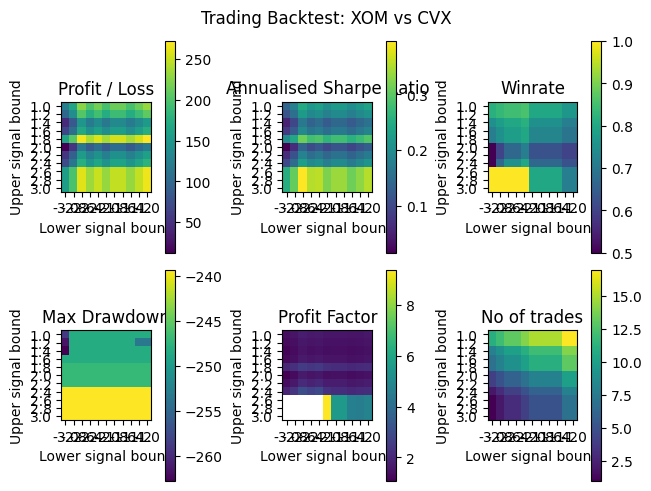

In [ ]:
fig, axs = plt.subplots(2, 3, constrained_layout=True)
axs[0,0].set_xticks(range(len(lowers)), labels=lowers)
axs[0,0].set_yticks(range(len(uppers)), labels=uppers)
pl_map = axs[0,0].imshow(pl_res)
axs[0,0].set_xlabel('Lower signal bound')
axs[0,0].set_ylabel('Upper signal bound')
axs[0,0].set_title('Profit / Loss')
fig.colorbar(pl_map, ax=axs[0,0])

axs[0,1].set_xticks(range(len(lowers)), labels=lowers)
axs[0,1].set_yticks(range(len(uppers)), labels=uppers)
ann_sharpes_map = axs[0,1].imshow(ann_sharpes)
axs[0,1].set_xlabel('Lower signal bound')
axs[0,1].set_ylabel('Upper signal bound')
axs[0,1].set_title('Annualised Sharpe Ratio')
fig.colorbar(ann_sharpes_map, ax=axs[0,1])

axs[0,2].set_xticks(range(len(lowers)), labels=lowers)
axs[0,2].set_yticks(range(len(uppers)), labels=uppers)
winrates_map = axs[0,2].imshow(winrates)
axs[0,2].set_xlabel('Lower signal bound')
axs[0,2].set_ylabel('Upper signal bound')
axs[0,2].set_title('Winrate')
fig.colorbar(winrates_map, ax=axs[0,2])

axs[1,0].set_xticks(range(len(lowers)), labels=lowers)
axs[1,0].set_yticks(range(len(uppers)), labels=uppers)
max_drawdowns_map = axs[1,0].imshow(max_drawdowns)
axs[1,0].set_xlabel('Lower signal bound')
axs[1,0].set_ylabel('Upper signal bound')
axs[1,0].set_title('Max Drawdown')
fig.colorbar(max_drawdowns_map, ax=axs[1,0])

axs[1,1].set_xticks(range(len(lowers)), labels=lowers)
axs[1,1].set_yticks(range(len(uppers)), labels=uppers)
profitfactors_map = axs[1,1].imshow(profitfactors)
axs[1,1].set_xlabel('Lower signal bound')
axs[1,1].set_ylabel('Upper signal bound')
axs[1,1].set_title('Profit Factor')
fig.colorbar(profitfactors_map, ax=axs[1,1])

axs[1,2].set_xticks(range(len(lowers)), labels=lowers)
axs[1,2].set_yticks(range(len(uppers)), labels=uppers)
ntrades_map = axs[1,2].imshow(ntrades)
axs[1,2].set_xlabel('Lower signal bound')
axs[1,2].set_ylabel('Upper signal bound')
axs[1,2].set_title('No of trades')
fig.colorbar(ntrades_map, ax=axs[1,2])
fig.suptitle('Trading Backtest: XOM vs CVX')

plt.show()

4. Out of sample testing

In [ ]:
xom = Stock('XOM_OOS.csv')
cvx = Stock('CVX_OOS.csv')
alphas = [np.nan] * window
betas = [np.nan] * window
for i in range(window, len(cvx.prices)):
    rolling_cvx_prices = cvx.prices[i - window:i]
    rolling_xom_prices = xom.prices[i - window:i]
    b, a, r, p, se = sp.stats.linregress(rolling_cvx_prices, rolling_xom_prices)
    alphas.append(a)
    betas.append(b)
residuals = xom.prices - alphas - betas * cvx.prices
# this is where you input your chosen signal bounds
u_bound, l_bound = (1.8, -1.0)
df , n_trades, trade_pl = pl_tester(u_bound, l_bound)

Out of sample results

In [ ]:
mean_daily_return = df['daily p/l'].mean()
std_daily_return = df['daily p/l'].std()
sharpe_daily = mean_daily_return / std_daily_return
sharpe_annual = sharpe_daily * np.sqrt(252)
wincount, totalwin, losscount, totalloss = (0, 0, 0, 0)
for net in trade_pl:
    if net > 0:
        wincount += 1
        totalwin += net
    elif net < 0:
        losscount += 1
        totalloss += net
if losscount == 0:
    avg_loss = 0
else:
    avg_loss = totalloss / losscount
if wincount == 0:
    avg_win = 0
else:
    avg_win = totalwin / wincount
if totalloss == 0:
    profit_factor = np.nan
else:
    profit_factor = totalwin / abs(totalloss)
winrate = wincount / n_trades
running_max = df['cumulative p/l'].cummax()
drawdown = df['cumulative p/l'] - running_max
max_drawdown = drawdown.min()
print('upper', u_bound, 'and lower', l_bound)
print('no of trades is ', n_trades, ',generating $', df['cumulative p/l'].iloc[-1])
print('avg win is', avg_win, ',avg loss is', avg_loss)
print('profit factor is', profit_factor)
print('max drawdown is', max_drawdown)
print('annualised sharpe is', sharpe_annual)
print(winrate, ' is the winrate')

upper 1.8 and lower -1.0
no of trades is  8 ,generating $ -83.2669410665351
avg win is 29.689735454188064 ,avg loss is -77.23853944582514
profit factor is 0.6406502864849473
max drawdown is -241.78120756686224
annualised sharpe is -0.24007914029311983
0.625  is the winrate
